In [1]:
from dotenv import load_dotenv
load_dotenv()

import os

if os.environ['GROQ_API_KEY']:
    print("API Key is Set!!!")
else:
    raise ValueError("API Key not loaded!!!")

API Key is Set!!!


In [2]:
from langchain_groq import ChatGroq
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

llm = ChatGroq(model="openai/gpt-oss-120b")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.0', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'GPT OSS 120B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001BA3A9BE150>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001BA3CFF6300>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

### **Tools**

### DuckDuckGo Search

In [3]:
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.tools import tool

@tool
def duckduckgo_tool(query:str):
    """This tool searches the duckduckgo for query"""

    duck_search = DuckDuckGoSearchRun()
    return duck_search.invoke(query)

C:\Users\btamm\AppData\Local\Temp\ipykernel_21452\2307119589.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import DuckDuckGoSearchRun


In [4]:
duckduckgo_tool.invoke("Anirudh Ravichander")

"Anirudh Ravichander (born 16 October 1990) is an Indian composer, playback singer, instrumentalist, and music producer who primarily works in Tamil cinema, with contributions to... AUDIO CREDITS: Song Title : Aravindh Composed by Anirudh Ravichander Lyrics by Super Subu Vocals by Anirudh Ravichander Composed, Arranged & Programmed by Anirudh Ravichander Keyboard, Synth ... Music Credits: Aaya Sher Album / Movie : The Paradise Composed by Anirudh Ravichander Lyrics - Kasarla Shyam Vocals - Addula Jangireddy, Arjun Chandy Composed, Arranged & Programmed by Anirudh ... Anirudh Ravichander's biography, age, family, career, education, net worth, wife, achievements, songs, and latest news in one detailed guide. Anirudh Ravichander, also known as simply Anirudh, is a celebrated Indian music composer and playback singer who has made music for movies in Tamil, Telugu, and Hindi languages. He shot to global fame because of the hugely popular viral video, Why This Kolaveri Di in the film 3, whic

### ArXiv Tool

In [5]:
import arxiv

@tool
def arxiv_tool(query: str) -> str:
    """
    Search arXiv and return summaries of the top papers.
    """

    client = arxiv.Client(
        page_size=3,
        delay_seconds=3,
        num_retries=5,
    )

    search = arxiv.Search(
        query=query,
        max_results=3,
        sort_by=arxiv.SortCriterion.Relevance,
    )

    papers = []

    try:
        for paper in client.results(search):
            papers.append(
                f"""
Title: {paper.title}

Authors: {", ".join(a.name for a in paper.authors)}

Published: {paper.published.date()}

Summary:
{paper.summary}
"""
            )

    except Exception as e:
        return f"Error: {e}"

    return  "\n".join(papers)

In [6]:
arxiv_tool.invoke({"query": "Transformers"})

'\nTitle: Physics-Informed Machine Learning for Transformer Condition Monitoring -- Part I: Basic Concepts, Neural Networks, and Variants\n\nAuthors: Jose I. Aizpurua\n\nPublished: 2025-12-20\n\nSummary:\nPower transformers are critical assets in power networks, whose reliability directly impacts grid resilience and stability. Traditional condition monitoring approaches, often rule-based or purely physics-based, struggle with uncertainty, limited data availability, and the complexity of modern operating conditions. Recent advances in machine learning (ML) provide powerful tools to complement and extend these methods, enabling more accurate diagnostics, prognostics, and control. In this two-part series, we examine the role of Neural Networks (NNs) and their extensions in transformer condition monitoring and health management tasks. This first paper introduces the basic concepts of NNs, explores Convolutional Neural Networks (CNNs) for condition monitoring using diverse data modalities, 

### Wikipedia Tool

In [7]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

@tool
def wiki_tool(query:str):
    """This tool allows you to search for wikipedia for a query"""
    
    wiki_query = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper())
    return wiki_query.invoke(query)

In [8]:
wiki_tool.invoke("Anirudh Ravichander")

'Page: Anirudh Ravichander\nSummary: Anirudh Ravichander (born 16 October 1990), also credited mononymously as Anirudh, is an Indian composer and playback singer who works primarily in Tamil cinema, in addition to Telugu and Hindi films. He has won two Filmfare Awards South, ten SIIMA Awards, six Edison Awards and five Vijay awards.\nHis debut song "Why This Kolaveri Di", composed for the 2012 film 3, went viral across the globe and has achieved over 590 million views on YouTube. A.R. Murugadoss signed him to compose music for Kaththi (2014) starring Vijay & Samantha which included the viral hit "Selfie Pulla". The soundtrack for the film became Anirudh\'s highest profile soundtrack until he was signed to compose music for Rajinikanth\'s Petta in 2019.\nIn 2016, he signed a record deal with Sony Music, which publishes his independent albums and live concerts. In the same year, he featured with Diplo on the remix of Major Lazer\'s hit single "Cold Water".\n\nPage: Anirudh Ravichander di

### Custom Tool

In [9]:
@tool
def personal_info(name:str):
    """Use this tool to get personal information about someone"""

    info={
        "Balaji":"Balaji is an AI Engineer.",
        "Ganesh":"Ganesh is Data Scientist",
        "Rohit Sharma":"Rohit Sharma is a cricketer"
    }

    return info.get(name, "No information found for this person!!!")

In [10]:
personal_info.invoke("Rohit Sharma")

'Rohit Sharma is a cricketer'

### **Tool Binding**

In [11]:
tools = [duckduckgo_tool,arxiv_tool,wiki_tool,personal_info]

llm_with_tools = llm.bind_tools(tools)

### **LangGraph Creation**

In [16]:
from typing import TypedDict, List
from langchain_core.messages import HumanMessage,ToolMessage

class graph_schema(TypedDict):
    messages: List

### Create Node Functions

In [15]:
from langchain_core.prompts import ChatPromptTemplate

def llm_node(state:graph_schema)->graph_schema:

    messages = state['messages']

    prompt = ChatPromptTemplate(
        [
            ("system","You are a helpful assitant to answer the questions using tools."),
            ("human","{input}")
        ]
    )

    chain = prompt | llm_with_tools

    response = chain.invoke({"input":messages})

    state['messages'] = messages + [response]

    return state

In [33]:
def tool_node(state:graph_schema)-> graph_schema:

    messages=state['messages']

    tools_by_name = {tool.name: tool for tool in tools}
    tool_results = []

    for tool_call in messages[-1].tool_calls:
        tool = tools_by_name[tool_call["name"]]
        observation = tool.invoke(tool_call["args"])
        tool_results.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))

    state['messages'] = messages + [tool_results]

    return state

### Create Conditional Node

In [34]:
from langgraph.graph import StateGraph, START, END

def if_tool_call(state:graph_schema)->str:

    last_message = state['messages'][-1]

    if last_message.tool_calls:
        return "tool_node"
    else:
        return "end"

### Create State Graph

In [35]:
graph = StateGraph(graph_schema)

# Add Nodes
graph.add_node("llm_node", llm_node)
graph.add_node("tool_node", tool_node)

# Add edges
graph.add_edge(START, "llm_node")
graph.add_conditional_edges("llm_node", if_tool_call,{"tool_node":"tool_node", "end":END})
graph.add_edge("tool_node","llm_node")
graph.add_edge("llm_node", END)

react_graph = graph.compile()

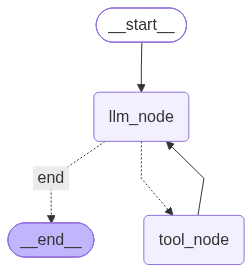

In [36]:
from IPython.display import Image, display

Image(react_graph.get_graph().draw_mermaid_png())

### Graph Invocation

In [37]:
react_graph.invoke({"messages": [HumanMessage(content="I want to know about Anirudh Ravichander")]})

{'messages': [HumanMessage(content='I want to know about Anirudh Ravichander', additional_kwargs={}, response_metadata={}),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'The user wants info about Anirudh Ravichander. Likely a musician/composer. We can search wiki.', 'tool_calls': [{'id': 'fc_4a954f31-e2cd-485b-b69a-0a7729b479b7', 'function': {'arguments': '{"query":"Anirudh Ravichander"}', 'name': 'wiki_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 58, 'prompt_tokens': 246, 'total_tokens': 304, 'completion_time': 0.1240667, 'completion_tokens_details': {'reasoning_tokens': 25}, 'prompt_time': 0.064382538, 'prompt_tokens_details': None, 'queue_time': 0.287943807, 'total_time': 0.188449238}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_5781dfb07c', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f8de2-992b-7173-b832-ed26064ba3ea-0', tool_ca

In [39]:
for chunk in react_graph.stream(
    {"messages": [HumanMessage(content="I want to know about Anirudh Ravichander")]},
    stream_mode="updates"
):
    print(chunk)

{'llm_node': {'messages': [HumanMessage(content='I want to know about Anirudh Ravichander', additional_kwargs={}, response_metadata={}), AIMessage(content='', additional_kwargs={'reasoning_content': 'The user wants to know about Anirudh Ravichander. We need to retrieve information. Likely a Wikipedia entry. Use wiki_tool.', 'tool_calls': [{'id': 'fc_542feb49-c1e5-48b1-b51c-59c33f40a0e2', 'function': {'arguments': '{"query":"Anirudh Ravichander"}', 'name': 'wiki_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 63, 'prompt_tokens': 246, 'total_tokens': 309, 'completion_time': 0.134795638, 'completion_tokens_details': {'reasoning_tokens': 30}, 'prompt_time': 0.067176383, 'prompt_tokens_details': None, 'queue_time': 0.168038743, 'total_time': 0.201972021}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_5a93aea882', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f8d

In [40]:
react_graph.invoke({"messages": [HumanMessage(content="What is the latest news on AI?")]})

{'messages': [HumanMessage(content='What is the latest news on AI?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "What is the latest news on AI?" Need to provide latest news. Should browse recent news. Use duckduckgo search for "latest AI news 2024". Use tool.', 'tool_calls': [{'id': 'fc_8c37d343-b7a6-46df-a407-a5b7858d1214', 'function': {'arguments': '{"query":"latest AI news 2024 July"}', 'name': 'duckduckgo_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 78, 'prompt_tokens': 242, 'total_tokens': 320, 'completion_time': 0.164308343, 'completion_tokens_details': {'reasoning_tokens': 42}, 'prompt_time': 0.009327297, 'prompt_tokens_details': None, 'queue_time': 0.313798497, 'total_time': 0.17363564}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_4140daa9c2', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider':

In [41]:
for chunk in react_graph.stream(
    {"messages": [HumanMessage(content="What is the latest news on AI?")]},
    stream_mode="updates"
):
    print(chunk)

{'llm_node': {'messages': [HumanMessage(content='What is the latest news on AI?', additional_kwargs={}, response_metadata={}), AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "What is the latest news on AI?" We need to provide latest news. We should browse recent news. Use duckduckgo search for "latest AI news 2024". Use tool.', 'tool_calls': [{'id': 'fc_403e91be-8e66-43ae-9f30-5252e7644406', 'function': {'arguments': '{"query":"latest AI news 2024 July"}', 'name': 'duckduckgo_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 80, 'prompt_tokens': 242, 'total_tokens': 322, 'completion_time': 0.170949617, 'completion_tokens_details': {'reasoning_tokens': 44}, 'prompt_time': 0.009302155, 'prompt_tokens_details': None, 'queue_time': 0.28092532, 'total_time': 0.180251772}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_90620edd96', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 